# Graphs regarding the three Plateus seen.

### The Plateus were seen with the following configurations.

Beta 0.8

TS = 2^17

Number Steps = 30000

Batch Size  = 128

Vocab size = 64

In [1]:
#Import packages 

import math
import torch
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
beta_value = 0.9                  #Seleccionamos beta
train_size= 2**17
#2^17

path = '/Users/julialand/Desktop/SISSA/RLM/experimentos_resultados/fixed/rlm_64L1_b0.8_ts131072_128_fix_'

nexp = 8

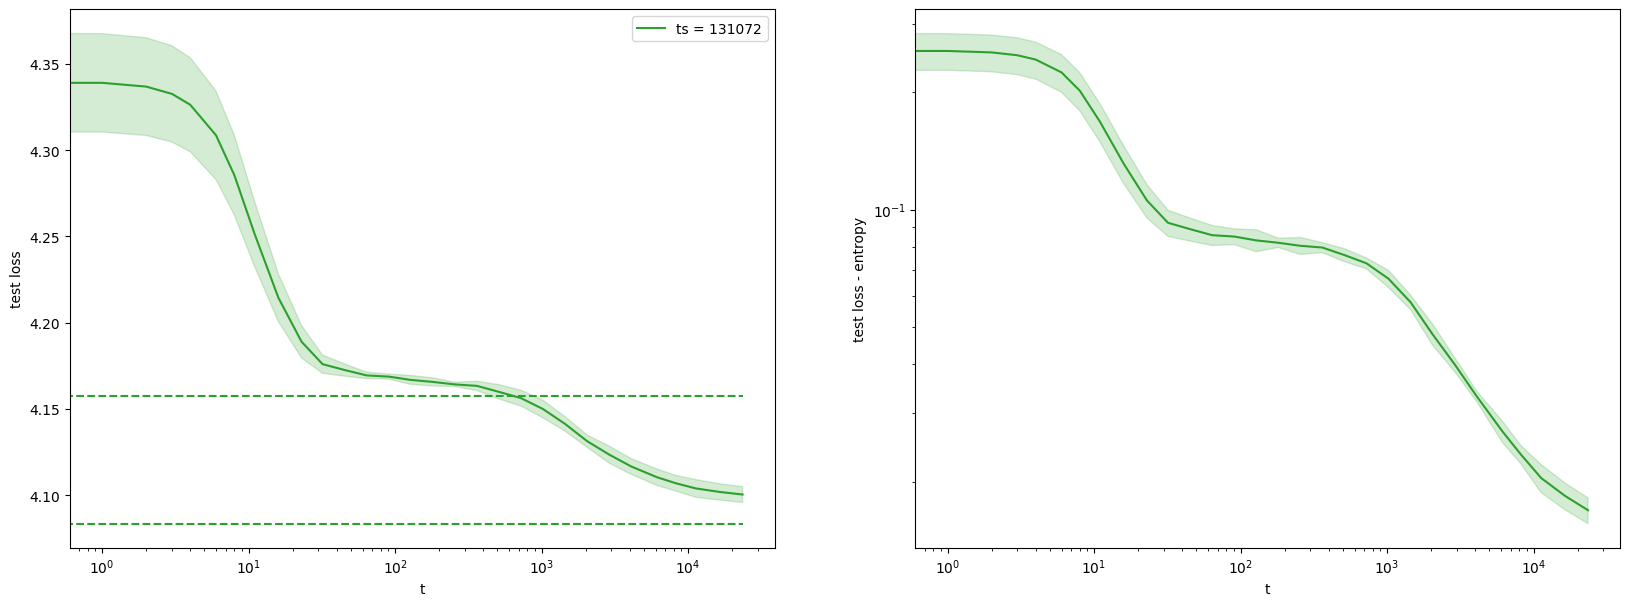

In [8]:
# Figura con dos paneles:
# izquierda: test loss promedio con banda ±σ y entropía promedio en línea punteada
# derecha: (test loss − entropy) promedio con banda ±σ
fig, ax = plt.subplots(1, 2, figsize=(20,7))


# Prefijo del nombre de archivo siguiendo tu convención


# Acumuladores por run
t_list = []      # tiempos por run (vector)
tl_list = []     # test loss por run (vector)
ent_list = []    # entropía por run (vector, replicado si originalmente es escalar)
marg_list = []
diff_list = []   # (test loss − entropy) por run (vector)
triv_entropy = []

# Recorremos runs 1..nexp
for i in range(1, nexp+1):
    # Carga de cada repetición
    # Nota: si tus .pt requieren modo "seguro", puedes usar add_safe_globals con argparse.Namespace
    res = torch.load(path + f'{i}.pt', map_location='cpu', weights_only=False)

    # Extraemos las series del dict
    dyn = res['output']['dynamics']     # lista de dicts por paso temporal
    ent = res['output']['entropy']      # escalar o serie
    marg = res['output']['marginal']    # escalar o serie

    # Convertimos a arrays NumPy para promediar
    t = np.asarray([d['t'] for d in dyn], dtype=float)
    tl = np.asarray([d['testloss'] for d in dyn], dtype=float)
    entr = np.asarray([math.log(64) for d in dyn], dtype=float)

    # Si la entropía es escalar, la replicamos al largo de t; si es serie, la recortamos
    if np.ndim(ent) == 0:
        ent_vec = np.full_like(t, float(ent))
    else:
        ent_vec = np.asarray(ent, dtype=float)[:len(t)]
    
    if np.ndim(marg) == 0:
        marg_vec = np.full_like(t, float(marg))
    else:
        marg_vec = np.asarray(marg, dtype=float)[:len(t)]

    # Guardamos cada run
    t_list.append(t)
    tl_list.append(tl)
    ent_list.append(ent_vec)
    marg_list.append(marg_vec)
    diff_list.append(tl - ent_vec)
    triv_entropy.append(entr)


# Alineamos longitudes: recortamos todas las series a la mínima longitud común L
L = min(len(x) for x in t_list)
T   = np.stack([x[:L] for x in t_list], axis=0)   # shape: [n_runs, L]
TL  = np.stack([x[:L] for x in tl_list], axis=0)  # shape: [n_runs, L]
ENT = np.stack([x[:L] for x in ent_list], axis=0) # shape: [n_runs, L]
MARG = np.stack([x[:L] for x in marg_list], axis=0) # shape: [n_runs, L]
DI  = np.stack([x[:L] for x in diff_list], axis=0)# shape: [n_runs, L]
triv_ENT = np.stack([x[:L] for x in triv_entropy], axis=0)# shape: [n_runs, L]

# Estadísticos por paso temporal (promedio y desviación estándar)
t_mean  = T.mean(axis=0)      # tiempo promedio (por si hay pequeñas diferencias entre runs)
tl_mean = TL.mean(axis=0)     # test loss promedio
tl_std  = TL.std(axis=0)      # σ de test loss
ent_mean = ENT.mean(axis=0)   # entropía promedio
marg_mean = MARG.mean(axis=0) # marginal promedio
di_mean = DI.mean(axis=0)     # (test loss − entropy) promedio
di_std  = DI.std(axis=0)      # σ de (test loss − entropy)
triv_ENT = triv_ENT.mean(axis=0)

# Color consistente por ts
c = f'C{train_size}'

# Panel izquierdo: test loss ±σ y entropía promedio (línea punteada)
ax[0].plot(t_mean, tl_mean, c, label=f'ts = {train_size}')
ax[0].plot()
ax[0].fill_between(t_mean, tl_mean - tl_std, tl_mean + tl_std, alpha=0.2, color=c)
ax[0].plot(t_mean, ent_mean, c, linestyle='dashed')
ax[0].plot(t_mean, marg_mean, c, linestyle='dashed')


# Panel derecho: (test loss − entropy) ±σ
ax[1].plot(t_mean, di_mean, c, label=f'ts = {train_size}')
ax[1].fill_between(t_mean, di_mean - di_std, di_mean + di_std, alpha=0.2, color=c)

# Formato y leyendas
ax[0].set_xscale('log')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[0].set_xlabel('t')
ax[1].set_xlabel('t')
ax[0].set_ylabel('test loss')
ax[1].set_ylabel('test loss - entropy')
ax[0].legend()

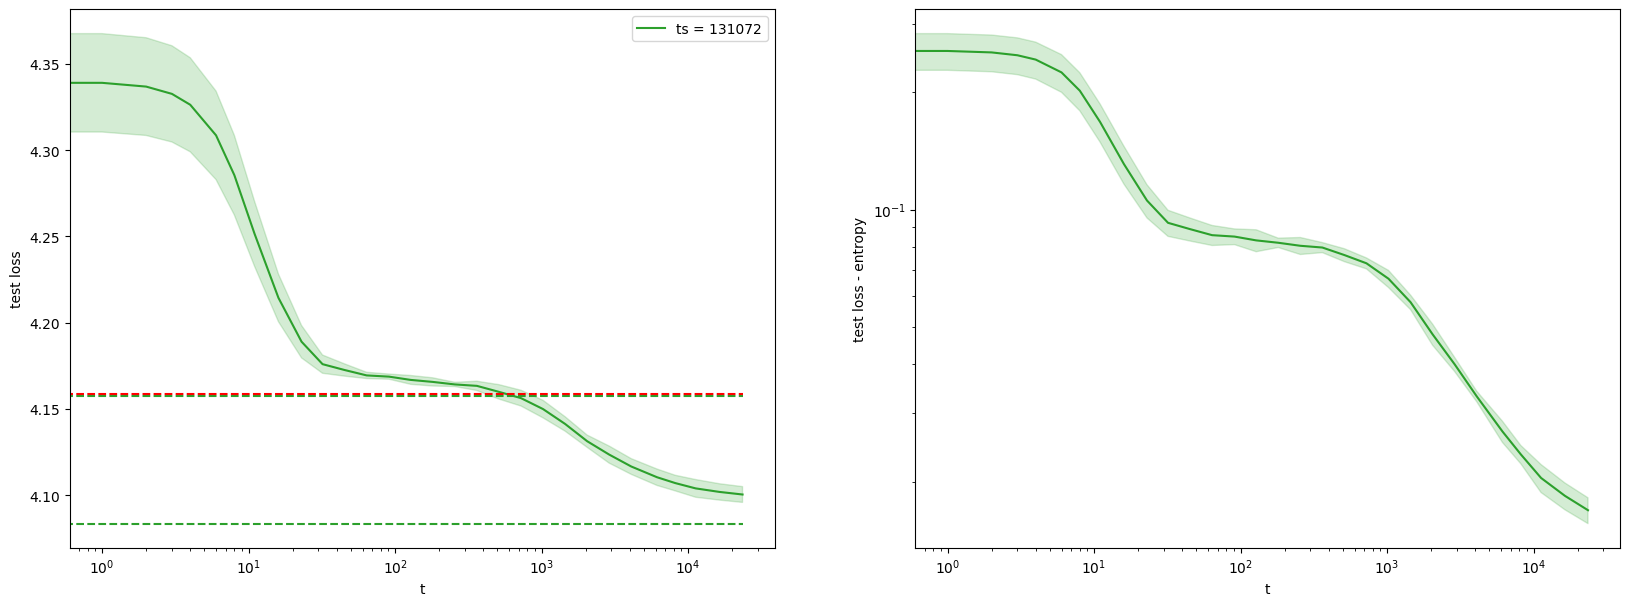

In [9]:
# Figura con dos paneles:
# izquierda: test loss promedio con banda ±σ y entropía promedio en línea punteada
# derecha: (test loss − entropy) promedio con banda ±σ
fig, ax = plt.subplots(1, 2, figsize=(20,7))


# Prefijo del nombre de archivo siguiendo tu convención


# Acumuladores por run
t_list = []      # tiempos por run (vector)
tl_list = []     # test loss por run (vector)
ent_list = []    # entropía por run (vector, replicado si originalmente es escalar)
marg_list = []
diff_list = []   # (test loss − entropy) por run (vector)
triv_entropy = []

# Recorremos runs 1..nexp
for i in range(1, nexp+1):
    # Carga de cada repetición
    # Nota: si tus .pt requieren modo "seguro", puedes usar add_safe_globals con argparse.Namespace
    res = torch.load(path + f'{i}.pt', map_location='cpu', weights_only=False)

    # Extraemos las series del dict
    dyn = res['output']['dynamics']     # lista de dicts por paso temporal
    ent = res['output']['entropy']      # escalar o serie
    marg = res['output']['marginal']    # escalar o serie

    # Convertimos a arrays NumPy para promediar
    t = np.asarray([d['t'] for d in dyn], dtype=float)
    tl = np.asarray([d['testloss'] for d in dyn], dtype=float)
    entr = np.asarray([math.log(64) for d in dyn], dtype=float)

    # Si la entropía es escalar, la replicamos al largo de t; si es serie, la recortamos
    if np.ndim(ent) == 0:
        ent_vec = np.full_like(t, float(ent))
    else:
        ent_vec = np.asarray(ent, dtype=float)[:len(t)]
    
    if np.ndim(marg) == 0:
        marg_vec = np.full_like(t, float(marg))
    else:
        marg_vec = np.asarray(marg, dtype=float)[:len(t)]

    # Guardamos cada run
    t_list.append(t)
    tl_list.append(tl)
    ent_list.append(ent_vec)
    marg_list.append(marg_vec)
    diff_list.append(tl - ent_vec)
    triv_entropy.append(entr)


# Alineamos longitudes: recortamos todas las series a la mínima longitud común L
L = min(len(x) for x in t_list)
T   = np.stack([x[:L] for x in t_list], axis=0)   # shape: [n_runs, L]
TL  = np.stack([x[:L] for x in tl_list], axis=0)  # shape: [n_runs, L]
ENT = np.stack([x[:L] for x in ent_list], axis=0) # shape: [n_runs, L]
MARG = np.stack([x[:L] for x in marg_list], axis=0) # shape: [n_runs, L]
DI  = np.stack([x[:L] for x in diff_list], axis=0)# shape: [n_runs, L]
triv_ENT = np.stack([x[:L] for x in triv_entropy], axis=0)# shape: [n_runs, L]

# Estadísticos por paso temporal (promedio y desviación estándar)
t_mean  = T.mean(axis=0)      # tiempo promedio (por si hay pequeñas diferencias entre runs)
tl_mean = TL.mean(axis=0)     # test loss promedio
tl_std  = TL.std(axis=0)      # σ de test loss
ent_mean = ENT.mean(axis=0)   # entropía promedio
marg_mean = MARG.mean(axis=0) # marginal promedio
di_mean = DI.mean(axis=0)     # (test loss − entropy) promedio
di_std  = DI.std(axis=0)      # σ de (test loss − entropy)
triv_ENT = triv_ENT.mean(axis=0)

# Color consistente por ts
c = f'C{train_size}'

# Panel izquierdo: test loss ±σ y entropía promedio (línea punteada)
ax[0].plot(t_mean, tl_mean, c, label=f'ts = {train_size}')
ax[0].plot()
ax[0].fill_between(t_mean, tl_mean - tl_std, tl_mean + tl_std, alpha=0.2, color=c)
ax[0].plot(t_mean, ent_mean, c, linestyle='dashed')
ax[0].plot(t_mean, marg_mean, c, linestyle='dashed')
ax[0].plot(t_mean, triv_ENT, 'red', linestyle='dashed')

# Panel derecho: (test loss − entropy) ±σ
ax[1].plot(t_mean, di_mean, c, label=f'ts = {train_size}')
ax[1].fill_between(t_mean, di_mean - di_std, di_mean + di_std, alpha=0.2, color=c)

# Formato y leyendas
ax[0].set_xscale('log')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[0].set_xlabel('t')
ax[1].set_xlabel('t')
ax[0].set_ylabel('test loss')
ax[1].set_ylabel('test loss - entropy')
ax[0].legend()